In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")



In [21]:
df = pd.read_csv("../data/winequality-red.csv", sep=";")

In [22]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred = model.predict(X_test_scaled)

In [27]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R^2: {r2:.3f}")

RMSE: 0.625
MAE: 0.504
R^2: 0.403


In [28]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

coefficients.sort_values(by="coefficient", ascending=False)

,feature,coefficient
10,alcohol,0.296628
9,sulphates,0.146815
5,free sulfur dioxide,0.058015
0,fixed acidity,0.039789
3,residual sugar,0.009421
7,density,-0.019204
2,citric acid,-0.027512
8,pH,-0.060610
4,chlorides,-0.089084
6,total sulfur dioxide,-0.120008


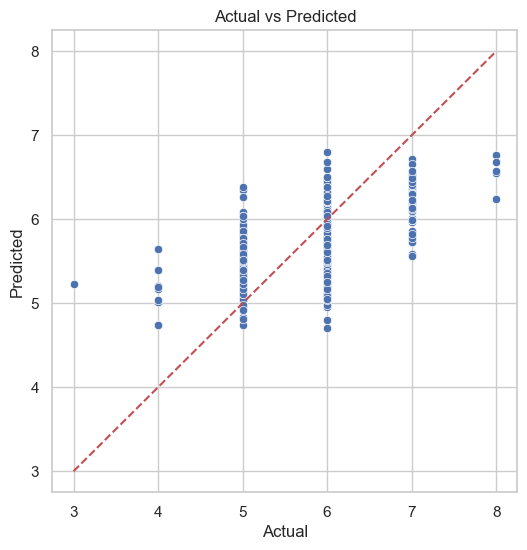

In [29]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=y_test, y=y_pred)

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

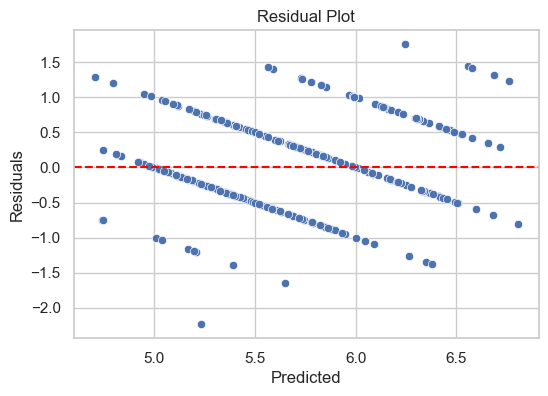

In [30]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

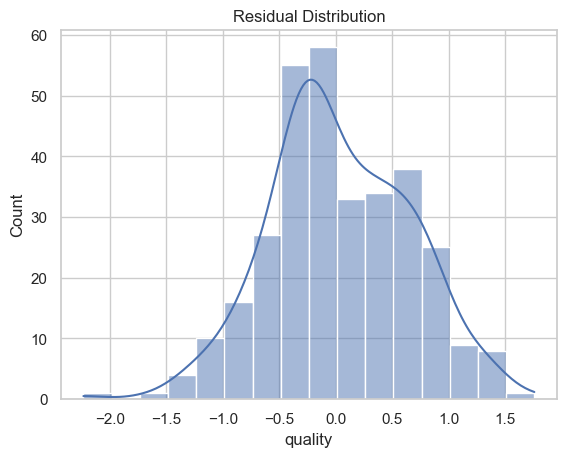

In [31]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [32]:
selected_features = ["alcohol", "volatile acidity"]

X_selected = df[selected_features]
y = df["quality"]

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_small = LinearRegression()
model_small.fit(X_train_scaled, y_train)

y_pred_small = model_small.predict(X_test_scaled)

In [39]:
coefficients = pd.DataFrame({
    "feature": X_selected.columns,
    "coefficient": model_small.coef_
})

coefficients.sort_values(by="coefficient", ascending=False)

,feature,coefficient
0,alcohol,0.331755
1,volatile acidity,-0.235439


In [35]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_small = np.sqrt(mean_squared_error(y_test, y_pred_small))
r2_small = r2_score(y_test, y_pred_small)

print(f"RMSE (2 features): {rmse_small:.3f}")
print(f"R^2 (2 features): {r2_small:.3f}")

RMSE (2 features): 0.646
R^2 (2 features): 0.361


In [36]:
comparison = pd.DataFrame({
    "Model": ["Full Model", "2-Feature Model"],
    "RMSE": [rmse, rmse_small],
    "R^2": [r2, r2_small]
})

comparison

,Model,RMSE,R^2
0,Full Model,0.624520,0.403180
1,2-Feature Model,0.646341,0.360746


In [37]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n = len(y_test)

adj_r2_full = adjusted_r2(r2, n, X.shape[1])
adj_r2_small = adjusted_r2(r2_small, n, 2)

print("Adj R² Full:", adj_r2_full)
print("Adj R² Small:", adj_r2_small)

Adj R² Full: 0.38186535346817985
Adj R² Small: 0.35671300883269186


In [38]:
from sklearn.model_selection import cross_val_score

rmse_full_cv = -cross_val_score(
    LinearRegression(),
    scaler.fit_transform(X),
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

rmse_small_cv = -cross_val_score(
    LinearRegression(),
    scaler.fit_transform(X_selected),
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

print("Full RMSE CV:", rmse_full_cv.mean())
print("Small RMSE CV:", rmse_small_cv.mean())

Full RMSE CV: 0.6606781143851868
Small RMSE CV: 0.6697533190706464
